# Fraud Detection Lab

#### Train and evaluate a predictive model to detect Fraud in financial transactions using a labelled dataset

#### The high-level tasks include:
- Select candidate machine learning algorithms
- Train a model and evaluate its peformance
- Perform cost analysis for model errors and adjust model parameters accordingly

#### The dataset `fraud.csv` contains the following columns:

1. **step**: Represents a unit of time.
2. **type**: The type of transaction (e.g., "CASH_OUT", "TRANSFER").
3. **amount**: The amount of the transaction.
4. **nameOrig**: The customer identifier for the origin.
5. **oldbalanceOrg**: The balance before the transaction for the origin account.
6. **newbalanceOrig**: The balance after the transaction for the origin account.
7. **nameDest**: The customer identifier for the destination.
8. **oldbalanceDest**: The balance before the transaction for the destination account.
9. **newbalanceDest**: The balance after the transaction for the destination account.
10. **isFraud**: The target variable indicating if the transaction is fraudulent (1 for fraud, 0 for non-fraud).



### Tasks:

##### **Part 1 - Data Import and Preparation**

- Data Preparation: This includes loading data, checking data types, and performing basic wrangling and encoding.
- Feature Engineering: Dropping high-cardinality features and applying one-hot encoding.
- Train-Test Split: Stratified split to maintain the class balance.
- Scaling: Using MinMaxScaler for numerical feature scaling.

##### **Part 2 - Explore ML Algorithms**
- Logistic Reggression
- KNN
- Random Forest Classifier

##### **Part 3 - Model Fine Tuning and Optimization**
- Observe how precision and recall respond to the choice of classification threshold
- Compute and plot the ROC Curve and AUC
- Optimize classification threshold for the cost of false positives and false negatives
- **Challenge:** optimize at least one significant hyperparameter (e.g., n_estimators or depth)


# **Part 1**

## 1. Import and inspect data

In [0]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

%matplotlib inline

In [0]:
data = pd.read_csv('https://raw.githubusercontent.com/wsko/Statistics/refs/heads/main/fraud.csv')

## data = spark.sql("select * from external_public_datasets.fraud").toPandas()

In [0]:
print("Dataset Overview:")
display(data.info())
print("\nMissing Data:")
print(data.isnull().sum())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318131 entries, 0 to 318130
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            318131 non-null  int64  
 1   type            318131 non-null  object 
 2   amount          318131 non-null  float64
 3   nameOrig        318131 non-null  object 
 4   oldbalanceOrg   318131 non-null  float64
 5   newbalanceOrig  318131 non-null  float64
 6   nameDest        318131 non-null  object 
 7   oldbalanceDest  318131 non-null  float64
 8   newbalanceDest  318131 non-null  float64
 9   isFraud         318131 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 24.3+ MB

Missing Data:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


In [0]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,345,CASH_OUT,76778.05,C2097594406,99108.00,22329.95,C386232205,0.00,76778.05,0
1,210,CASH_OUT,107058.17,C171085292,123258.57,16200.40,C1839284889,524851.98,631910.15,0
2,37,CASH_IN,43381.03,C856782994,50085.00,93466.03,C2036456346,0.00,0.00,0
3,256,CASH_OUT,67749.17,C717698638,0.00,0.00,C1537680105,405026.26,472775.43,0
4,43,TRANSFER,628687.17,C1189390198,0.00,0.00,C1621505394,763012.87,1391700.05,0


## 2. Identify issues with data qulity and perform feature transformations

In [0]:

# Check for unique values in each column to find high-cardinality categorical features
unique_counts = data.nunique()
print("\nUnique values in each column:\n", unique_counts)


Unique values in each column:
 step                 556
type                   5
amount            314561
nameOrig          318105
oldbalanceOrg     144845
newbalanceOrig    137279
nameDest          260660
oldbalanceDest    182669
newbalanceDest    194807
isFraud                2
dtype: int64


In [0]:
data.describe(include = 'object')

,type,nameOrig,nameDest
count,318131,318131,318131
unique,5,318105,260660
top,CASH_OUT,C844722675,C920011586
freq,111654,2,9


In [0]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,318131.000000,3.181310e+05,3.181310e+05,3.181310e+05,3.181310e+05,3.181310e+05,318131.000000
mean,243.283311,1.792642e+05,8.366934e+05,8.582686e+05,1.103309e+06,1.227016e+06,0.001232
std,142.454685,6.157749e+05,2.909752e+06,2.946199e+06,3.433999e+06,3.727797e+06,0.035081
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,155.000000,1.334288e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,238.000000,7.464965e+04,1.406900e+04,0.000000e+00,1.313952e+05,2.146350e+05,0.000000
75%,335.000000,2.088555e+05,1.066465e+05,1.431042e+05,9.461707e+05,1.113669e+06,0.000000
max,743.000000,6.173376e+07,3.575571e+07,3.589244e+07,3.279630e+08,3.281945e+08,1.000000


## 3. Remove high-cardinality categorical variables

In [0]:
data = data.drop(columns=['nameOrig', 'nameDest'])
data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,345,CASH_OUT,76778.05,99108.00,22329.95,0.00,76778.05,0
1,210,CASH_OUT,107058.17,123258.57,16200.40,524851.98,631910.15,0
2,37,CASH_IN,43381.03,50085.00,93466.03,0.00,0.00,0
3,256,CASH_OUT,67749.17,0.00,0.00,405026.26,472775.43,0
4,43,TRANSFER,628687.17,0.00,0.00,763012.87,1391700.05,0


## 4. Perform one hot encoding for the remaining categorical variables

In [0]:

data = pd.get_dummies(data, drop_first=True)  # Perform one-hot encoding on categorical columns of 'data', dropping the first category to avoid multicollinearity

data.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,345,76778.05,99108.00,22329.95,0.00,76778.05,0,1,0,0,0
1,210,107058.17,123258.57,16200.40,524851.98,631910.15,0,1,0,0,0
2,37,43381.03,50085.00,93466.03,0.00,0.00,0,0,0,0,0
3,256,67749.17,0.00,0.00,405026.26,472775.43,0,1,0,0,0
4,43,628687.17,0.00,0.00,763012.87,1391700.05,0,0,0,0,1


## 5. Create data arrays
- `X` (features) and `y` (label)

In [0]:

X = data.drop(columns=['isFraud']).to_numpy().astype('float')  # Extract features (excluding 'isFraud') as a NumPy array and convert to float type
y = data['isFraud'].to_numpy()  # Extract the target variable 'isFraud' as a NumPy array
feature_names = data.columns[data.columns != 'isFraud']  # Get feature names by excluding the 'isFraud' column


In [0]:
print(X.shape)  # Display the shape (rows, columns) of the feature matrix 'X'
print(y.shape)
print(feature_names)

(318131, 10)
(318131,)
Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='object')


## 6. Perform train-test-splitting

In [0]:
X_train, X_test, y_train, y_test = train_test_split(  # Split the dataset into training and testing sets
    X, y,  # Features (X) and target labels (y)
    test_size=0.2,  # Use 20% of the data for testing
    stratify=y,  # Ensure the split maintains the same class proportions as in the original data
    random_state=42  # Set random state for reproducibility of the split
)


# Verify the ratio of positive to negative examples in train and test sets
print("Training set fraud ratio:", y_train.mean())
print("Test set fraud ratio:", y_test.mean())

Training set fraud ratio: 0.0012337723572124603
Test set fraud ratio: 0.001225894667358197


In [0]:
X_train.shape

(254504, 10)

## 7. Scale numerical variables
- with **MinMaxScaler**

In [0]:

scaler = MinMaxScaler()  # Initialize MinMaxScaler to scale features between 0 and 1
X_train = scaler.fit_transform(X_train)  # Fit the scaler on the training data and transform it
X_test = scaler.transform(X_test)  # Apply the trained scaler to the test data (without fitting again)


---

# **Part 2**

## 8. Train and Evaluate a Logistic Regression Model


#### **Problem Statement**
- Predict if a transaction is fradulentet

#### **Model Training**
- Train a logistc regression model on the training set

In [0]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score  # Import metrics for model evaluation
from sklearn.linear_model import LogisticRegression  # Import Logistic Regression for classification modeling


In [0]:
lr = LogisticRegression()  # Initialize a Logistic Regression model
lr.fit(X_train, y_train)  # Train the model using the training data (X_train as features and y_train as target labels)



Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run unruly-deer-940 at: https://intuit-e2-739275435815-exploration-prd.cloud.databricks.com/ml/experiments/1397920799842068/runs/255ba62c0856405982a83068782348d0
🧪 View experiment at: https://intuit-e2-739275435815-exploration-prd.cloud.databricks.com/ml/experiments/1397920799842068


LogisticRegression()

#### **Model Evaluation**
- Compute predicted labels for the test set
- Evaluate the model by comparing the predicted and actual laels using:
- >confusion matrix
- >accuracy, precision and recall

In [0]:
y_pred = lr.predict(X_test)  # Predict the target labels for the test data using the trained Logistic Regression model


In [0]:
# Function to plot the confusion matrix
def plot_confusion_matrix(model, X_test, y_test):
    # Compute y_pred
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Negative', 'Positive'], rotation=45)
    plt.yticks(tick_marks, ['Negative', 'Positive'])

    # Print confusion matrix values on the plot
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, f'{cm[i, j]}',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

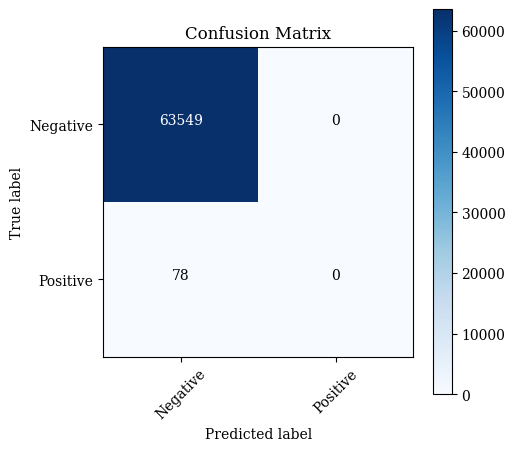

In [0]:
plot_confusion_matrix(lr,X_test, y_test)

In [0]:
def evaluate_classifier(model, X_test, y_test):
    # Compute y_pred
    y_pred = model.predict(X_test)

    # Compute precision, recall, and accuracy
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    # Display the results
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Accuracy: {accuracy:.4f}")


In [0]:
evaluate_classifier(lr, X_test, y_test)

Precision: 0.0000
Recall: 0.0000
Accuracy: 0.9988


## 9. **Your Turn**: Train, evaluate and rank classification models
- >KNN classifier
- >Random forest classifier
- >Gradient boost classifier

In [0]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.ensemble import GradientBoostingClassifier

In [0]:
#  rf = RandomForestClassifier()
# rf.fit(FIXME)
# plot_confusion_matrix(FIXME)
# evaluate_classifier(FIXME)



# knn = ...
# your code here

### **Rank the classifiers based on model precision and recall**


### Precision

1.
2.
3.

### Recall

1.
2.
3.

---
# **Part 3. Model Optimization**

## Fine tune the Random Forest model
- Observe how precision and recall respond to the choice of classification threshold
- Compute and plot the ROC Curve and AUC
- Optimize classification threshold for the cost of false positives and false negatives
- **Challenge:** optimize at least one significant hyperparameter (e.g., n_estimators or depth)

## 10. Train the model and evaluate performance metrics at different thresholds

In [0]:
rf = RandomForestClassifier()  # Initialize a Random Forest classifier
rf.fit(X_train, y_train)  # Train the Random Forest model using the training data


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run wise-bird-516 at: https://intuit-e2-739275435815-exploration-prd.cloud.databricks.com/ml/experiments/1397920799842068/runs/26bfdf0eb7384159a885ee6314f06227
🧪 View experiment at: https://intuit-e2-739275435815-exploration-prd.cloud.databricks.com/ml/experiments/1397920799842068


RandomForestClassifier()

In [0]:
# Function to plot the confusion matrix with custom threshold
def plot_confusion_matri_with_threshold(model, X_test, y_test, threshold = 0.5):
    # Get the predicted probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Apply the threshold to get binary predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Threshold = ' + str(threshold))
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Negative', 'Positive'], rotation=45)
    plt.yticks(tick_marks, ['Negative', 'Positive'])

    # Print confusion matrix values on the plot
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, f'{cm[i, j]}',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [0]:
def evaluate_classifier_with_threshold(model, X_test, y_test, threshold = 0.5):
    # Get the predicted probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]
    # Apply the threshold to get binary predictions
    y_pred = (y_prob >= threshold).astype(int)
    # Compute precision, recall, and accuracy
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    # Display the results
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Accuracy: {accuracy:.4f}")


### Threshold Experiments:

- vary prediction threshold between 0.99 and 0.01
- observe the effect of threshold on precision and recall

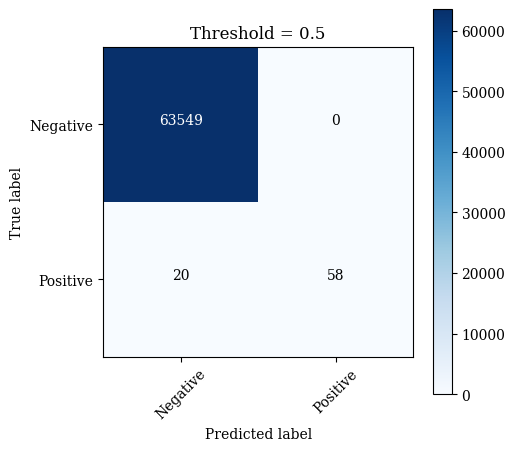

Precision: 1.0000
Recall: 0.7436
Accuracy: 0.9997


In [0]:
threshold = 0.5  # Set the decision threshold for classification


plot_confusion_matri_with_threshold(rf,X_test, y_test, threshold)
evaluate_classifier_with_threshold(rf, X_test, y_test, threshold)

## 11. Plot and inspect the ROC Curve
- How good is your model?
- What is the AUC?

In [0]:
from sklearn.metrics import roc_curve, roc_auc_score  # Import ROC curve and AUC score metrics
import matplotlib.pyplot as plt  # Import Matplotlib for plotting

def plot_roc_curve(model, y_true):  # Define a function to plot ROC curve for a given model and true labels
    y_proba = model.predict_proba(X_test)[:, 1]  # Get the predicted probabilities for the positive class (1)

    # Compute the ROC curve (FPR: False Positive Rate, TPR: True Positive Rate, thresholds: Classification thresholds)
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc_score = roc_auc_score(y_true, y_proba)  # Calculate the AUC (Area Under the Curve) score for further evaluation

    # Plot the ROC curve
    plt.figure(figsize=(8, 6))  # Set up the figure size
    plt.plot(fpr, tpr, label=f"(AUC = {auc_score:.2f})")  # Plot True Positive Rate against False Positive Rate
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Plot a diagonal reference line for random predictions
    plt.xlabel("False Positive Rate")  # Label the x-axis
    plt.ylabel("True Positive Rate")  # Label the y-axis
    plt.title("ROC Curve")  # Add a title to the plot
    plt.legend()  # Display the legend with AUC and reference line
    plt.show()  # Render the ROC curve plot

    return auc_score  # Return the AUC score for further analysis



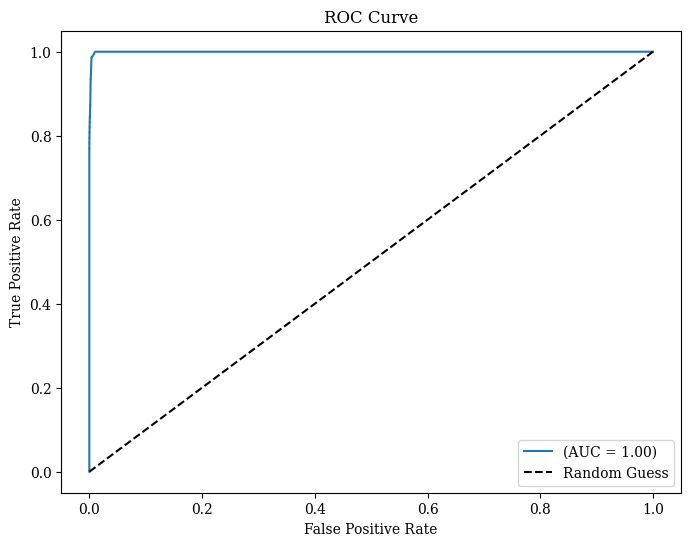

AUC Score: 0.9995508210704358


In [0]:

auc = plot_roc_curve(rf, y_test)
print("AUC Score:", auc)

## 12. Threshold Optimization for the cost of Type I and Type II Errors

In [0]:
model = rf

# Cost for false positives (still fixed)
cost_false_positive = 500

# Adjust threshold to minimize total cost
thresholds = np.arange(0.01, 0.99, 0.01)
costs = []

# Get predicted probabilities only once
y_proba = model.predict_proba(X_test)[:, 1]

for threshold in thresholds:
    y_pred_adjusted = (y_proba >= threshold).astype(int)

    # Boolean masks
    fn_mask = (y_pred_adjusted == 0) & (y_test == 1)
    fp_mask = (y_pred_adjusted == 1) & (y_test == 0)

    # False negative cost = sum of transaction amounts of missed frauds
    fn_cost = X_test[fn_mask, 1].sum()

    # False positive cost = fixed cost * number of false positives
    fp_cost = fp_mask.sum() * cost_false_positive

    total_cost = fn_cost + fp_cost
    costs.append(total_cost)


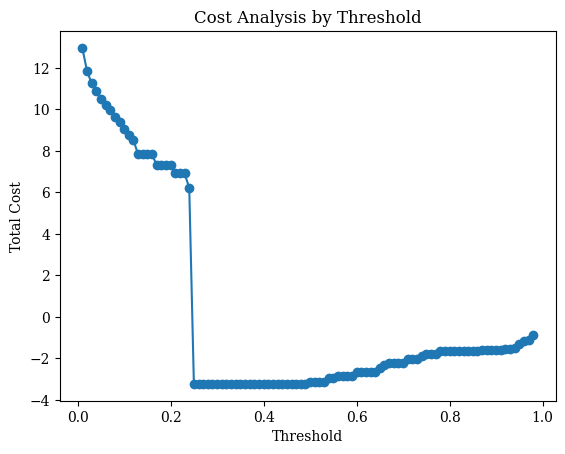

Optimal threshold: 0.25


In [0]:
# Plot the cost vs. threshold
plt.plot(thresholds, np.log(costs), marker='o')
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Cost Analysis by Threshold")
#plt.ylim(0, 1000000)
plt.show()

print("Optimal threshold:", thresholds[np.argmin(costs)])

## 13. **Challenge:** Hyperparameter Optimization

- Conduct a grid search to optimize two key hyperparameters of a Random Forest classifier: n_estimators and max_depth.
- Use an experimental grid with 3 values for each hyperparameter.
- Aim to identify the best hyperparameter combination that maximizes performance, measured by AUC (Area Under the Curve) using k-fold cross-validation.
- Visualize the results in a heatmap for clear comparison across combinations.
- Highlight the best-performing hyperparameter configuration.

In [0]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

In [0]:
# Define hyperparameter grid
n_estimators_values = [20, 60, 200]  # 3 values for n_estimators
max_depth_values = [3, 9, 27]         # 3 values for max_depth

In [0]:
# Store results
cv_auc_scores = []
grid_results = []

# Grid search
for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        # 2-fold cross-validation on the training set
        auc = cross_val_score(model, X_train, y_train, cv=2, scoring="roc_auc") #select the nuber of folds
        mean_auc = np.mean(auc)
        cv_auc_scores.append(mean_auc)
        grid_results.append((n_estimators, max_depth, mean_auc))

        print(f"n_estimators={n_estimators}, max_depth={max_depth}, Mean CV AUC={mean_auc:.3f}")

# Convert results into a structured matrix for visualization
cv_auc_matrix = np.array(cv_auc_scores).reshape(len(n_estimators_values), len(max_depth_values))


n_estimators=20, max_depth=3, Mean CV AUC=0.971
n_estimators=20, max_depth=9, Mean CV AUC=0.994
n_estimators=20, max_depth=27, Mean CV AUC=0.956
n_estimators=60, max_depth=3, Mean CV AUC=0.970
n_estimators=60, max_depth=9, Mean CV AUC=0.996
n_estimators=60, max_depth=27, Mean CV AUC=0.977
n_estimators=200, max_depth=3, Mean CV AUC=0.974
n_estimators=200, max_depth=9, Mean CV AUC=0.996
n_estimators=200, max_depth=27, Mean CV AUC=0.986


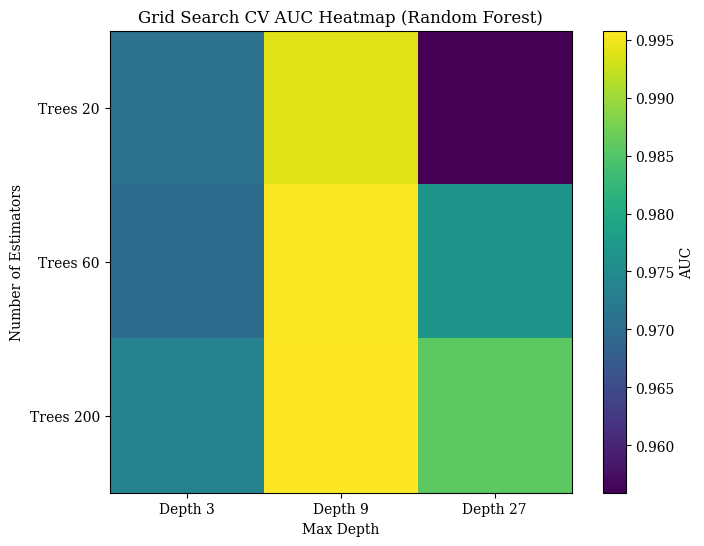

Best combination: n_estimators=200, max_depth=9 with Mean CV AUC=0.996


In [0]:

# Plot AUC heatmap
plt.figure(figsize=(8, 6))
plt.imshow(cv_auc_matrix, interpolation="nearest", cmap="viridis")
plt.colorbar(label="AUC")
plt.xticks(range(len(max_depth_values)), [f"Depth {d}" for d in max_depth_values])
plt.yticks(range(len(n_estimators_values)), [f"Trees {n}" for n in n_estimators_values])
plt.xlabel("Max Depth")
plt.ylabel("Number of Estimators")
plt.title("Grid Search CV AUC Heatmap (Random Forest)")
plt.show()

# Optionally, display the best combination
best_combo = max(grid_results, key=lambda x: x[2])
print(f"Best combination: n_estimators={best_combo[0]}, max_depth={best_combo[1]} with Mean CV AUC={best_combo[2]:.3f}")